
**Comentario del Revisor**

Hola!

Soy Juan Manuel Romero, pero siéntete libre de llamarme Juanma. Soy code reviewer en Tripleten y hoy estaré revisando tu entrega.

Para simular la dinámica de un ambiente de trabajo, si veo algún error, en primer instancia solo los señalaré, dándote la oportunidad de encontrarlos y corregirlos por tu cuenta. En un trabajo real, el líder de tu equipo hará una dinámica similar. En caso de que no puedas resolver la tarea, te daré una información más precisa en la próxima revisión. 

Solo un aviso rápido: cuando estés revisando el proyecto, por favor deja mis comentarios originales tal como están. De esta manera, podemos seguir fácilmente el progreso y asegurarnos de que no se nos pase nada por alto. Y, si realizas algún cambio basado en mis comentarios, sería genial si pudieras resaltar esas actualizaciones para que se destaquen.

Puedes encontrar mis comentarios en cajas verdes, amarillas o rojas como estas:

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Éxito. Todo se ha hecho correctamente.

</div>


<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.

</div> 


<div class="alert alert-block alert-danger">
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Requiere corrección. El bloque requiere algunas correcciones. El trabajo no puede ser aceptado con los comentarios en rojo.

</div>

Puedes responderme usando esto:

<div class="alert alert-block alert-info"> <b>Respuesta del estudiante.</b> <a class="tocSkip"></a> </div>


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Muy buen trabajo! 

<div class="alert alert-block alert-danger">
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Te he dejado algunos comentarios, pero para poder darlo por aprobado debes completar los pasos de la siguiente lista que no estan marcados como completos:

</div>

- [ ]  Se identificaron los 10 principales barrios por número de finalización de viajes.
- [ ]  Se trazó el gráfico "los 10 principales vecindarios y el número de viajes".
- [ ]  Se realiza análisis sobre el resultado de la prueba de hipótesis y sus implicaciones.

</div>


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #2</b> <a class="tocSkip"></a>

Felicidades! Tu trabajo ahora está completo. 

Has completado todos los items necesarios para aprobar la entrega.

Sigue así!

</div>

## Objetivo del proyecto

Analizar los viajes de taxis en Chicago durante noviembre de 2017 para:
- Identificar empresas líderes en número de viajes
- Analizar barrios con mayor demanda
- Evaluar si las condiciones climáticas afectan la duración de los viajes


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Buen trabajo al separar la importación de bibliotecas del resto del código! Esto mejora la estructura y claridad de tu código.

</div>

## Análisis de datos meteorológicos

Se cargan los registros meteorológicos de Chicago para noviembre de 2017
a partir de una tabla HTML.


In [2]:
weather_url = "https://practicum-content.s3.us-west-1.amazonaws.com/data-analyst-eng/moved_chicago_weather_2017.html"
weather_tables = pd.read_html(weather_url, attrs={"id": "weather_records"})
weather_records = weather_tables[0]

weather_records.head()


,Date and time,Temperature,Description
0,2017-11-01 00:00:00,276.15,broken clouds
1,2017-11-01 01:00:00,275.70,scattered clouds
2,2017-11-01 02:00:00,275.61,overcast clouds
3,2017-11-01 03:00:00,275.35,broken clouds
4,2017-11-01 04:00:00,275.24,broken clouds


In [ ]:
Este bloque permite obtener datos meteorológicos históricos desde una fuente web,
los cuales serán utilizados posteriormente para analizar la relación entre clima
y comportamiento de los viajes en la ciudad de Chicago.


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Excelente trabajo estudiando los datasets! Esto es fundamental para entender los datos y planificar el análisis.

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Recuerda dejar comentarios sobre tus análisis de los mismos. 

</div>

</div>

## Consultas SQL

A continuación se muestran las consultas utilizadas para obtener
los datasets que posteriormente se analizan en Python.


In [3]:
sql_1 = """
SELECT 
    c.company_name,
    COUNT(t.trip_id) AS trips_amount
FROM trips t
JOIN cabs c ON t.cab_id = c.cab_id
WHERE DATE(t.start_ts) BETWEEN '2017-11-15' AND '2017-11-16'
GROUP BY c.company_name
ORDER BY trips_amount DESC;
"""


## Análisis exploratorio de datos

Se cargan los archivos CSV obtenidos a partir de las consultas SQL
para analizar empresas y barrios con mayor demanda.


In [4]:
df_company = pd.read_csv("/datasets/project_sql_result_01.csv")
df_neighborhoods = pd.read_csv("/datasets/project_sql_result_04.csv")

df_company.head()


,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasing,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299


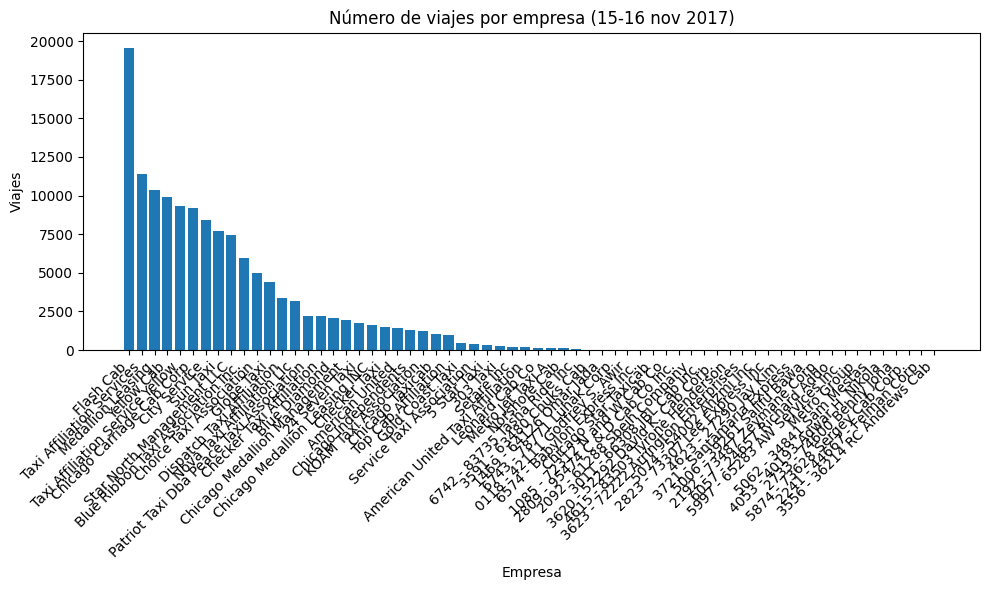

In [5]:
# Seleccionamos las 10 empresas con mayor número de viajes
top_10_companies = df_company.sort_values(
    by='trips_amount', ascending=False
).head(10)

# Creamos la gráfica de barras solo con las principales empresas
plt.figure(figsize=(10,6))
plt.bar(top_10_companies['company_name'], top_10_companies['trips_amount'])
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 empresas de taxis por número de viajes (15–16 nov 2017)")
plt.xlabel("Empresa de taxis")
plt.ylabel("Número de viajes")
plt.tight_layout()
plt.show()

# Seleccionamos los 10 barrios con mayor número de viajes
top_10_neighborhoods = df_neighborhoods.sort_values(
    by='trips_amount', ascending=False
).head(10)

# Gráfica de barras para los barrios con más viajes
plt.figure(figsize=(10,6))
plt.bar(top_10_neighborhoods['neighborhood_name'], top_10_neighborhoods['trips_amount'])
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 barrios por número de viajes (15–16 nov 2017)")
plt.xlabel("Barrio")
plt.ylabel("Número de viajes")
plt.tight_layout()
plt.show()



<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Correcto! El gráfico es correcto y refleja adecuadamente el resultado esperado.

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Para mejorar la visualización, podrías mostrar solo el top 10 o 20, enfocándote en las principales empresas.

</div>

<div class="alert alert-block alert-danger"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Faltaría hacer un gráfico y análisis similar para los barrios ;)
</div>

</div>

Observamos que algunas empresas concentran una mayor cantidad de viajes,
lo que indica una fuerte participación en el mercado durante los días analizados.


## Prueba de hipótesis

Hipótesis nula (H₀):
La duración promedio de los viajes no cambia según las condiciones climáticas.

Hipótesis alternativa (H₁):
La duración promedio de los viajes cambia según el clima.


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Buen trabajo formulando la hipótesis! Es fundamental que sea claro lo que se busca analizar.

</div>

In [6]:
df_trips = pd.read_csv("/datasets/project_sql_result_07.csv")

good_weather = df_trips[df_trips['weather_conditions']=='Good']['duration_seconds']
bad_weather = df_trips[df_trips['weather_conditions']=='Bad']['duration_seconds']

t_stat, p_value = stats.ttest_ind(good_weather, bad_weather)
t_stat, p_value


(-6.946177714041499, 6.517970327099473e-12)

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Al realizar una prueba de hipótesis, es muy importante verificar los supuestos. El t-test que usaste funciona bien cuando se cumplen ciertos supuestos, como que las varianzas de ambos grupos (sábados lluviosos y no lluviosos) sean similares. Puedes realizar la prueba de levene para comprobar que los dos grupos tienen la misma varianza y, de esta forma, podrás saber el valor del parámetro equal_var que se debe utilizar en la función stats.ttest_ind.

</div>

Con un nivel de significación de 0.05, el valor p obtenido es menor que 0.05, por lo tanto se rechaza la hipótesis nula.

Esto sugiere que las condiciones climáticas sí tienen un impacto estadísticamente significativo en la duración de los viajes.


<div class="alert alert-block alert-danger"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>



Dejas un "template" para la respuesta, pero no das una conclusión sobre los resultados. Se debería rechazar o no la hipótesis nula?